In [8]:
import pandas as pd
import numpy as np

columns = [
    "user_id",
    "item_id",
    "category_id",
    "behavior_type",
    "timestamp"
]

df = pd.read_csv(
    "../data/samples/sample_5M.csv",
    names=columns,
    header=None
)

print("Shape:", df.shape)

df.head()

Shape: (5000000, 5)


,user_id,item_id,category_id,behavior_type,timestamp
0,57451,2654395,2196412,pv,1512087991
1,739293,2238431,901282,pv,1512230965
2,778355,5060381,982926,pv,1512225718
3,124947,2631776,3004643,pv,1511759635
4,732733,3625486,622741,pv,1512277730


In [9]:
print("Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nBehavior Types:")
print(df["behavior_type"].value_counts())

print("\nData Types:")
print(df.dtypes)

Shape: (5000000, 5)

Missing Values:
user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
dtype: int64

Duplicate Rows:
0

Behavior Types:
behavior_type
pv      4477238
cart     277476
fav      144415
buy      100871
Name: count, dtype: int64

Data Types:
user_id          int64
item_id          int64
category_id      int64
behavior_type      str
timestamp        int64
dtype: object


In [10]:
df["datetime"] = pd.to_datetime(
    df["timestamp"],
    unit="s"
)

df["date"] = df["datetime"].dt.date
df["hour"] = df["datetime"].dt.hour
df["day"] = df["datetime"].dt.day_name()

print(df["datetime"].min())
print(df["datetime"].max())

df.head()

1905-07-13 14:06:35
2030-01-16 12:52:42


,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,day
0,57451,2654395,2196412,pv,1512087991,2017-12-01 00:26:31,2017-12-01,0,Friday
1,739293,2238431,901282,pv,1512230965,2017-12-02 16:09:25,2017-12-02,16,Saturday
2,778355,5060381,982926,pv,1512225718,2017-12-02 14:41:58,2017-12-02,14,Saturday
3,124947,2631776,3004643,pv,1511759635,2017-11-27 05:13:55,2017-11-27,5,Monday
4,732733,3625486,622741,pv,1512277730,2017-12-03 05:08:50,2017-12-03,5,Sunday


In [11]:
print("Min timestamp:", df["timestamp"].min())
print("Max timestamp:", df["timestamp"].max())

df.sort_values("timestamp").head(10)

Min timestamp: -2034496405
Max timestamp: 1894798362


,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,day
4557681,49210,3713509,1467750,pv,-2034496405,1905-07-13 14:06:35,1905-07-13,14,Thursday
2478811,734649,2755307,2465336,pv,-1631962208,1918-04-15 13:09:52,1918-04-15,13,Monday
2442513,353279,986346,1879194,pv,-1270954491,1929-09-22 21:05:09,1929-09-22,21,Sunday
3518148,1000606,4016423,5147460,pv,682374481,1991-08-16 20:28:01,1991-08-16,20,Friday
1396954,483928,1800961,2355072,pv,729372219,1993-02-10 19:23:39,1993-02-10,19,Wednesday
2410557,815863,1573904,149192,pv,1354406375,2012-12-01 23:59:35,2012-12-01,23,Saturday
524740,815863,1823800,2520377,pv,1354406815,2012-12-02 00:06:55,2012-12-02,0,Sunday
425162,815863,2026395,2520377,pv,1354407322,2012-12-02 00:15:22,2012-12-02,0,Sunday
4987088,815863,2423933,4756105,pv,1354410192,2012-12-02 01:03:12,2012-12-02,1,Sunday
551566,499697,3118356,2096639,pv,1354507187,2012-12-03 03:59:47,2012-12-03,3,Monday


In [12]:
df.sort_values("timestamp", ascending=False).head(10)

,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,day
4778422,29956,3794949,2188684,pv,1894798362,2030-01-16 12:52:42,2030-01-16,12,Wednesday
2159590,433433,966563,2982027,pv,1761956275,2025-11-01 00:17:55,2025-11-01,0,Saturday
738577,823589,3886108,514392,pv,1761661971,2025-10-28 14:32:51,2025-10-28,14,Tuesday
2322690,823589,5069517,2096639,pv,1761628781,2025-10-28 05:19:41,2025-10-28,5,Tuesday
1756706,823589,154974,1051370,pv,1761572805,2025-10-27 13:46:45,2025-10-27,13,Monday
693384,823589,3624315,1051370,pv,1761572764,2025-10-27 13:46:04,2025-10-27,13,Monday
2009652,823589,5105574,3768664,pv,1761572511,2025-10-27 13:41:51,2025-10-27,13,Monday
182839,698507,3004797,1766039,pv,1761350292,2025-10-24 23:58:12,2025-10-24,23,Friday
4323891,698507,2226758,4869837,pv,1761318007,2025-10-24 15:00:07,2025-10-24,15,Friday
4876206,642694,4963824,4267003,pv,1760872977,2025-10-19 11:22:57,2025-10-19,11,Sunday


In [13]:
start_ts = pd.Timestamp("2017-11-25").timestamp()
end_ts = pd.Timestamp("2017-12-04").timestamp()

invalid = df[
    (df["timestamp"] < start_ts) |
    (df["timestamp"] > end_ts)
]

print("Invalid rows:", len(invalid))
print("Percentage:", round(len(invalid)/len(df)*100, 4), "%")

invalid.head()

Invalid rows: 62185
Percentage: 1.2437 %


,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,day
58,100,2971043,4869428,pv,1511550885,2017-11-24 19:14:45,2017-11-24,19,Friday
65,100,5100093,2945933,pv,1511552352,2017-11-24 19:39:12,2017-11-24,19,Friday
74,436535,442334,4357323,pv,1511541504,2017-11-24 16:38:24,2017-11-24,16,Friday
91,438550,2502925,2778281,pv,1511567820,2017-11-24 23:57:00,2017-11-24,23,Friday
92,762707,855702,2728585,pv,1511553180,2017-11-24 19:53:00,2017-11-24,19,Friday


In [14]:
valid_df = df[
    (df["timestamp"] >= start_ts) &
    (df["timestamp"] <= end_ts)
].copy()

print("Rows after filtering:", len(valid_df))

Rows after filtering: 4937815


In [15]:
df = df[
    (df["timestamp"] >= start_ts) &
    (df["timestamp"] <= end_ts)
].copy()

df.reset_index(drop=True, inplace=True)

print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Final Shape: (4937815, 9)

Missing Values:
user_id          0
item_id          0
category_id      0
behavior_type    0
timestamp        0
datetime         0
date             0
hour             0
day              0
dtype: int64

Duplicate Rows:
0


In [16]:
df.to_parquet(
    "../data/processed/clean_data.parquet",
    index=False
)

print("Saved successfully")

Saved successfully


In [17]:
import os

print(
    round(
        os.path.getsize(
            "../data/processed/clean_data.parquet"
        ) / (1024**2),
        2
    ),
    "MB"
)

115.03 MB


In [18]:
df.to_parquet(
    "../data/processed/clean_data.parquet",
    index=False
)

print("Saved successfully")

Saved successfully


In [19]:
import os

size_mb = os.path.getsize(
    "../data/processed/clean_data.parquet"
) / (1024**2)

print(f"File Size: {size_mb:.2f} MB")

File Size: 115.03 MB


In [20]:
print(df.shape)

df.head()

(4937815, 9)


,user_id,item_id,category_id,behavior_type,timestamp,datetime,date,hour,day
0,57451,2654395,2196412,pv,1512087991,2017-12-01 00:26:31,2017-12-01,0,Friday
1,739293,2238431,901282,pv,1512230965,2017-12-02 16:09:25,2017-12-02,16,Saturday
2,778355,5060381,982926,pv,1512225718,2017-12-02 14:41:58,2017-12-02,14,Saturday
3,124947,2631776,3004643,pv,1511759635,2017-11-27 05:13:55,2017-11-27,5,Monday
4,732733,3625486,622741,pv,1512277730,2017-12-03 05:08:50,2017-12-03,5,Sunday


In [21]:
import pandas as pd
import numpy as np

# Load cleaned data
df = pd.read_parquet("../data/processed/clean_data.parquet")

# ══ TEMPORAL FEATURES ══════════════════════════════

df["hour_of_day"] = df["datetime"].dt.hour
df["day_of_week"] = df["datetime"].dt.day_name()
df["is_weekend"] = df["datetime"].dt.dayofweek.isin([5, 6]).astype("int8")
df["minute"] = df["datetime"].dt.minute
df["week_num"] = df["datetime"].dt.isocalendar().week.astype("int16")


def hour_segment(h):
    if 0 <= h < 6:
        return "Late Night"
    elif h < 12:
        return "Morning"
    elif h < 14:
        return "Lunch"
    elif h < 18:
        return "Afternoon"
    elif h < 22:
        return "Evening"
    else:
        return "Night"


df["hour_segment"] = df["hour_of_day"].apply(hour_segment)

# ══ USER JOURNEY FEATURES ═══════════════════════════

df["prev_action"] = (
    df.groupby("user_id")["behavior_type"]
      .shift(1)
)

df["next_action"] = (
    df.groupby("user_id")["behavior_type"]
      .shift(-1)
)

df["action_sequence"] = (
    df["prev_action"].fillna("START")
    + "→"
    + df["behavior_type"]
)

# ══ SESSIONIZATION ═════════════════════════════════

SESSION_GAP = 30 * 60

df["time_diff"] = (
    df.groupby("user_id")["timestamp"]
      .diff()
      .fillna(0)
)

df["new_session"] = (
    (df["time_diff"] > SESSION_GAP)
    | (df["time_diff"] == 0)
)

df["session_id"] = (
    df.groupby("user_id")["new_session"]
      .cumsum()
)

df["session_id"] = (
    df["user_id"].astype(str)
    + "_S"
    + df["session_id"].astype(str)
)

# ══ BEHAVIORAL FEATURES ════════════════════════════

user_stats = (
    df.groupby("user_id")
      .agg(
          total_actions=("behavior_type", "count"),
          converted=("behavior_type",
                     lambda x: int((x == "buy").any())),
          favorited=("behavior_type",
                     lambda x: int((x == "fav").any())),
          carted=("behavior_type",
                  lambda x: int((x == "cart").any())),
          viewed=("behavior_type",
                  lambda x: int((x == "pv").any()))
      )
      .reset_index()
)

# ══ USER SEGMENTATION ══════════════════════════════

def segment_user(row):
    if row["converted"] == 1:
        return "Buyer"
    elif row["carted"] == 1:
        return "Cart Abandoner"
    elif row["favorited"] == 1:
        return "Wishlist Browser"
    else:
        return "Passive Viewer"


user_stats["user_segment"] = (
    user_stats.apply(segment_user, axis=1)
)

df = df.merge(
    user_stats[["user_id", "user_segment"]],
    on="user_id",
    how="left"
)

print("Feature engineering complete")
print(df.shape)

Feature engineering complete
(4937815, 22)


In [22]:
df[[
    "behavior_type",
    "hour_segment",
    "prev_action",
    "next_action",
    "time_diff",
    "session_id",
    "user_segment"
]].head(10)

,behavior_type,hour_segment,prev_action,next_action,time_diff,session_id,user_segment
0,pv,Late Night,NaN,fav,0.0,57451_S1,Wishlist Browser
1,pv,Afternoon,NaN,pv,0.0,739293_S1,Buyer
2,pv,Afternoon,NaN,pv,0.0,778355_S1,Passive Viewer
3,pv,Late Night,NaN,pv,0.0,124947_S1,Cart Abandoner
4,pv,Late Night,NaN,pv,0.0,732733_S1,Passive Viewer
5,fav,Morning,NaN,pv,0.0,543097_S1,Wishlist Browser
6,pv,Afternoon,NaN,pv,0.0,866320_S1,Cart Abandoner
7,pv,Lunch,NaN,pv,0.0,17597_S1,Cart Abandoner
8,pv,Evening,NaN,pv,0.0,1_S1,Passive Viewer
9,pv,Late Night,NaN,pv,0.0,398216_S1,Buyer


In [23]:
# ════════════════════════════════════════════════
# SORT DATA FIRST (IMPORTANT)
# ════════════════════════════════════════════════

df = df.sort_values(
    ["user_id", "datetime"]
).reset_index(drop=True)

print("Data sorted successfully")

# ════════════════════════════════════════════════
# USER JOURNEY FEATURES
# ════════════════════════════════════════════════

df["prev_action"] = (
    df.groupby("user_id")["behavior_type"]
      .shift(1)
)

df["next_action"] = (
    df.groupby("user_id")["behavior_type"]
      .shift(-1)
)

df["action_sequence"] = (
    df["prev_action"]
      .fillna("START")
      + "→"
      + df["behavior_type"]
)

print("Journey features created")

# ════════════════════════════════════════════════
# SESSIONIZATION
# ════════════════════════════════════════════════

SESSION_GAP = 30 * 60  # 30 minutes

df["time_diff"] = (
    df.groupby("user_id")["timestamp"]
      .diff()
      .fillna(0)
)

df["new_session"] = (
    (df["time_diff"] > SESSION_GAP)
    | (df["time_diff"] == 0)
)

df["session_num"] = (
    df.groupby("user_id")["new_session"]
      .cumsum()
)

df["session_id"] = (
    df["user_id"].astype(str)
    + "_S"
    + df["session_num"].astype(str)
)

print("Sessionization complete")

# ════════════════════════════════════════════════
# VERIFY RESULTS
# ════════════════════════════════════════════════

df[
    [
        "user_id",
        "behavior_type",
        "prev_action",
        "next_action",
        "time_diff",
        "session_id"
    ]
].head(20)

Data sorted successfully
Journey features created
Sessionization complete


,user_id,behavior_type,prev_action,next_action,time_diff,session_id
0,1,pv,NaN,pv,0.0,1_S1
1,1,pv,pv,pv,25357.0,1_S2
2,1,pv,pv,pv,104836.0,1_S3
3,1,pv,pv,pv,129279.0,1_S4
4,1,pv,pv,pv,60015.0,1_S5
...,...,...,...,...,...,...
15,3,pv,cart,pv,52407.0,3_S5
16,3,pv,pv,pv,29494.0,3_S6
17,3,pv,pv,NaN,76994.0,3_S7
18,4,pv,NaN,pv,0.0,4_S1


In [24]:
df.to_parquet(
    "../data/processed/featured_data.parquet",
    index=False
)

user_stats.to_parquet(
    "../data/processed/user_stats.parquet",
    index=False
)

print("✓ featured_data.parquet saved")
print("✓ user_stats.parquet saved")

✓ featured_data.parquet saved
✓ user_stats.parquet saved


In [25]:
import os

print(
    "featured_data:",
    round(
        os.path.getsize(
            "../data/processed/featured_data.parquet"
        ) / (1024**2),
        2
    ),
    "MB"
)

print(
    "user_stats:",
    round(
        os.path.getsize(
            "../data/processed/user_stats.parquet"
        ) / (1024**2),
        2
    ),
    "MB"
)

featured_data: 146.02 MB
user_stats: 2.29 MB


In [26]:
df.to_parquet("../data/processed/featured_data.parquet", index=False)

In [27]:
# Bot Detection Analysis

In [28]:
actions_per_user = (
    df.groupby("user_id")
      .size()
)

print(actions_per_user.describe())

count    376483.000000
mean         13.115639
std          11.496732
min           1.000000
25%           5.000000
50%          10.000000
75%          18.000000
max         121.000000
dtype: float64


In [29]:
zero_gap_counts = (
    df[df["time_diff"] <= 1]
      .groupby("user_id")
      .size()
)

print(zero_gap_counts.describe())

count    376483.000000
mean          1.016147
std           0.157042
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          26.000000
dtype: float64


In [30]:
actions_per_user = (
    df.groupby("user_id")
      .size()
)

Q1 = actions_per_user.quantile(0.25)
Q3 = actions_per_user.quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Upper Bound:", upper_bound)

suspicious_users = actions_per_user[
    actions_per_user > upper_bound
]

print("Suspicious Users:", len(suspicious_users))

Q1: 5.0
Q3: 18.0
IQR: 13.0
Upper Bound: 37.5
Suspicious Users: 17099


In [31]:
df["high_activity_user"] = (
    df["user_id"]
      .isin(suspicious_users.index)
      .astype(int)
)

In [32]:
repeat_actions = (
    df.groupby(
        ["user_id", "item_id", "behavior_type"]
    )
    .size()
)

print(repeat_actions.describe())

count    4.728079e+06
mean     1.044360e+00
std      2.488932e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      2.200000e+01
dtype: float64


In [33]:
print(
    repeat_actions
    .sort_values(ascending=False)
    .head(20)
)

user_id  item_id  behavior_type
518431   2493767  pv               22
116139   4305129  pv               21
         862880   pv               20
607519   2571554  pv               17
970695   987027   pv               15
                                   ..
973081   1770999  pv               12
189865   3781210  pv               12
916181   2147182  pv               12
48907    4669006  pv               12
114892   2698233  pv               12
Length: 20, dtype: int64


In [36]:
# ==========================================
# BOT DETECTION USING SESSION ANALYSIS
# ==========================================

import pandas as pd
import numpy as np

# ------------------------------------------
# Session Summary
# ------------------------------------------

session_summary = (
    df.groupby("session_id")
      .agg(
          user_id=("user_id", "first"),
          session_start=("timestamp", "min"),
          session_end=("timestamp", "max"),
          actions=("behavior_type", "count")
      )
      .reset_index()
)

session_summary["session_duration"] = (
    session_summary["session_end"]
    - session_summary["session_start"]
)

print("Total Sessions:", len(session_summary))

# ------------------------------------------
# Zero Duration Sessions
# ------------------------------------------

same_timestamp_sessions = session_summary[
    session_summary["session_duration"] == 0
]

print(
    "Zero-duration sessions:",
    len(same_timestamp_sessions)
)

print(
    "Percentage:",
    round(
        len(same_timestamp_sessions)
        / len(session_summary)
        * 100,
        2
    ),
    "%"
)

# ------------------------------------------
# Users generating many zero-duration sessions
# ------------------------------------------

zero_session_users = (
    same_timestamp_sessions
    .groupby("user_id")
    .size()
)

print("\nUsers with most zero-duration sessions:")
print(
    zero_session_users
    .sort_values(ascending=False)
    .head(20)
)

# ------------------------------------------
# High Activity Users
# ------------------------------------------

actions_per_user = (
    df.groupby("user_id")
      .size()
)

Q1 = actions_per_user.quantile(0.25)
Q3 = actions_per_user.quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

high_activity_users = actions_per_user[
    actions_per_user > upper_bound
]

print("\nHigh Activity Users:", len(high_activity_users))
print("Threshold:", upper_bound)

# ------------------------------------------
# Repetitive Behaviour
# ------------------------------------------

repeat_actions = (
    df.groupby(
        ["user_id", "item_id", "behavior_type"]
    )
    .size()
)

repetitive_users = (
    repeat_actions[repeat_actions > 20]
    .index.get_level_values(0)
    .unique()
)

print(
    "\nUsers repeating same action >20 times:",
    len(repetitive_users)
)

# ------------------------------------------
# Bot Score
# ------------------------------------------

zero_session_flag = set(
    zero_session_users[
        zero_session_users > 5
    ].index
)

high_activity_flag = set(
    high_activity_users.index
)

repetition_flag = set(
    repetitive_users
)

suspected_bots = (
    zero_session_flag
    & high_activity_flag
) | (
    zero_session_flag
    & repetition_flag
)

print("\nSuspected Bots:", len(suspected_bots))

# ------------------------------------------
# Create Flag Instead of Deleting
# ------------------------------------------

df["bot_flag"] = (
    df["user_id"]
      .isin(suspected_bots)
      .astype(int)
)

print(
    "\nBot Flag Distribution:"
)

print(
    df["bot_flag"]
      .value_counts()
)

Total Sessions: 2753235
Zero-duration sessions: 1684427
Percentage: 61.18 %

Users with most zero-duration sessions:
user_id
116139    39
444499    37
380644    36
583180    35
605741    34
          ..
314336    29
93088     29
630574    29
660835    29
817041    29
Length: 20, dtype: int64

High Activity Users: 17099
Threshold: 37.5

Users repeating same action >20 times: 2

Suspected Bots: 13404

Bot Flag Distribution:
bot_flag
0    4290351
1     647464
Name: count, dtype: int64


In [37]:
suspected_bot_df = df[
    df["user_id"].isin(suspected_bots)
]

normal_df = df[
    ~df["user_id"].isin(suspected_bots)
]

print("Bot Users:", suspected_bot_df["user_id"].nunique())
print("Normal Users:", normal_df["user_id"].nunique())

print("\nBot Behaviour Distribution")
print(
    suspected_bot_df["behavior_type"]
    .value_counts(normalize=True)
    * 100
)

print("\nNormal Behaviour Distribution")
print(
    normal_df["behavior_type"]
    .value_counts(normalize=True)
    * 100
)

Bot Users: 13404
Normal Users: 363079

Bot Behaviour Distribution
behavior_type
pv      91.523699
cart     4.321476
fav      3.008353
buy      1.146473
Name: proportion, dtype: float64

Normal Behaviour Distribution
behavior_type
pv      89.231441
cart     5.739927
fav      2.869602
buy      2.159031
Name: proportion, dtype: float64


In [38]:
df.to_parquet(
    "../data/processed/final_dataset.parquet",
    index=False
)

print(df.shape)

(4937815, 25)


In [39]:
funnel = {
    "View": df[df["behavior_type"] == "pv"]["user_id"].nunique(),
    "Favorite": df[df["behavior_type"] == "fav"]["user_id"].nunique(),
    "Cart": df[df["behavior_type"] == "cart"]["user_id"].nunique(),
    "Purchase": df[df["behavior_type"] == "buy"]["user_id"].nunique()
}

for stage, count in funnel.items():
    print(f"{stage:<10}: {count:,}")

View      : 371,758
Favorite  : 68,400
Cart      : 145,098
Purchase  : 78,609


In [40]:
v2f = funnel["Favorite"] / funnel["View"] * 100
f2c = funnel["Cart"] / funnel["Favorite"] * 100
c2p = funnel["Purchase"] / funnel["Cart"] * 100
v2p = funnel["Purchase"] / funnel["View"] * 100

cart_abandonment = 100 - c2p

print(f"View → Favorite : {v2f:.2f}%")
print(f"Favorite → Cart : {f2c:.2f}%")
print(f"Cart → Purchase : {c2p:.2f}%")
print(f"View → Purchase : {v2p:.2f}%")
print(f"Cart Abandonment: {cart_abandonment:.2f}%")

View → Favorite : 18.40%
Favorite → Cart : 212.13%
Cart → Purchase : 54.18%
View → Purchase : 21.15%
Cart Abandonment: 45.82%


In [41]:
segment_counts = (
    df["user_segment"]
    .value_counts()
)

print(segment_counts)

user_segment
Cart Abandoner      1784707
Buyer               1308085
Passive Viewer      1272554
Wishlist Browser     572469
Name: count, dtype: int64


In [42]:
hourly_buy = (
    df[df["behavior_type"] == "buy"]
    .groupby("hour_of_day")
    .size()
)

print(hourly_buy)

hour_of_day
0     3219
1     4866
2     6449
3     6015
4     5896
      ... 
19     341
20     315
21     357
22     836
23    1706
Length: 24, dtype: int64


In [43]:
segment_pct = (
    df["user_segment"]
    .value_counts(normalize=True)
    * 100
)

print(segment_pct)

user_segment
Cart Abandoner      36.143659
Buyer               26.491171
Passive Viewer      25.771601
Wishlist Browser    11.593569
Name: proportion, dtype: float64


In [44]:
hourly_buy = (
    df[df["behavior_type"] == "buy"]
    .groupby("hour_of_day")
    .size()
    .sort_index()
)

print(hourly_buy.to_string())

hour_of_day
0     3219
1     4866
2     6449
3     6015
4     5896
5     6160
6     6226
7     6160
8     6061
9     5158
10    4764
11    5785
12    6616
13    7239
14    6718
15    5028
16    2538
17    1042
18     558
19     341
20     315
21     357
22     836
23    1706


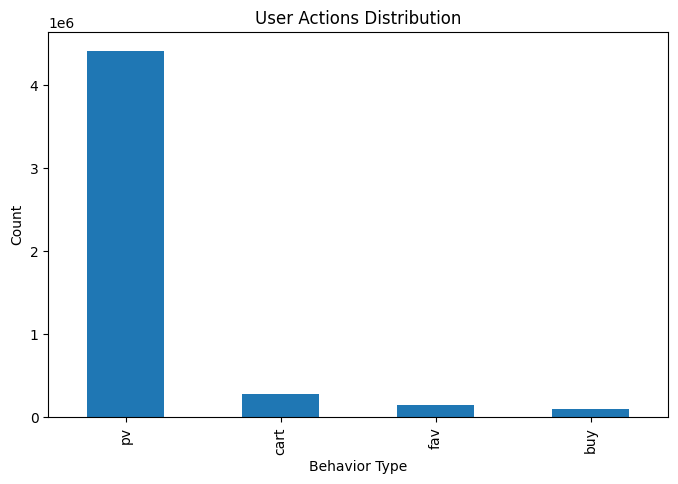

In [45]:
import matplotlib.pyplot as plt

action_counts = (
    df["behavior_type"]
    .value_counts()
)

plt.figure(figsize=(8,5))

action_counts.plot(kind="bar")

plt.title("User Actions Distribution")
plt.xlabel("Behavior Type")
plt.ylabel("Count")

plt.show()

In [46]:
# ---------------------------------------------------------
# Category Conversion Analysis
# Objective:
# Identify product categories with the strongest conversion
# performance by comparing purchases against product views.
# These categories represent areas where customer intent
# successfully translates into transactions.
# ---------------------------------------------------------

category_stats = (
    df.groupby("category_id")
      .agg(
          views=(
              "behavior_type",
              lambda x: (x == "pv").sum()
          ),
          purchases=(
              "behavior_type",
              lambda x: (x == "buy").sum()
          )
      )
)

# Calculate conversion rate as:
# Purchases / Views × 100
category_stats["conversion_rate"] = (
    category_stats["purchases"]
    / category_stats["views"]
    * 100
)

# Categories with very few views can produce misleadingly
# high conversion rates, so retain only categories with
# meaningful traffic volume.
category_stats = category_stats[
    category_stats["views"] >= 100
]

# Rank categories by conversion performance
category_stats = (
    category_stats
    .sort_values(
        "conversion_rate",
        ascending=False
    )
)

# Display the highest converting categories
category_stats.head(20)

,views,purchases,conversion_rate
category_id,,,
1421972,115,68,59.130435
194104,103,51,49.514563
804084,271,80,29.520295
63690,216,49,22.685185
2025483,181,38,20.994475
...,...,...,...
2550060,185,30,16.216216
2100611,145,23,15.862069
1461887,101,16,15.841584


In [47]:
# Focus on categories with meaningful traffic

reliable_categories = (
    category_stats[
        category_stats["views"] >= 500
    ]
    .sort_values(
        "conversion_rate",
        ascending=False
    )
)

reliable_categories.head(20)

,views,purchases,conversion_rate
category_id,,,
85955,1050,187,17.809524
772894,533,79,14.821764
1025720,508,74,14.566929
2321836,780,106,13.589744
970709,859,112,13.038417
...,...,...,...
3164550,640,68,10.625000
2794147,707,75,10.608204
4331400,748,78,10.427807


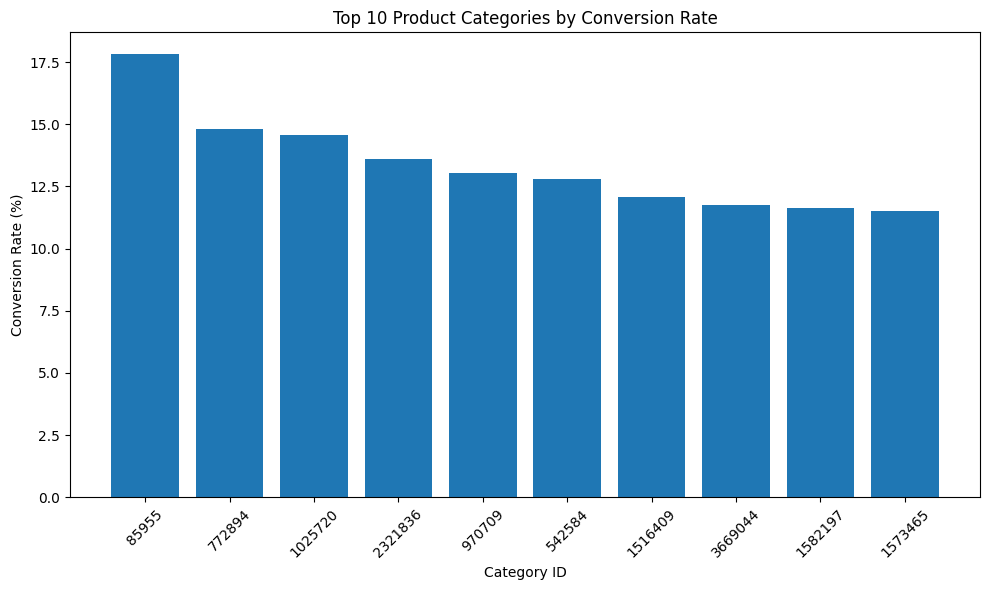

In [48]:
# ---------------------------------------------------------
# Top Converting Product Categories
#
# Objective:
# Identify categories that generate the highest proportion
# of purchases relative to product views.
#
# Business Context:
# High-converting categories indicate strong customer intent
# and should be prioritized for promotions and inventory.
# ---------------------------------------------------------

top_categories = (
    reliable_categories
    .head(10)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(
    top_categories.index.astype(str),
    top_categories["conversion_rate"]
)

plt.title(
    "Top 10 Product Categories by Conversion Rate"
)

plt.xlabel("Category ID")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [49]:
hourly_stats = (
    df.groupby("hour_of_day")
      .agg(
          views=("behavior_type",
                 lambda x: (x == "pv").sum()),
          purchases=("behavior_type",
                     lambda x: (x == "buy").sum())
      )
)

hourly_stats["conversion_rate"] = (
    hourly_stats["purchases"]
    / hourly_stats["views"]
    * 100
)

hourly_stats

,views,purchases,conversion_rate
hour_of_day,,,
0,152474,3219,2.111180
1,185898,4866,2.617564
2,215819,6449,2.988152
3,210613,6015,2.855949
4,212286,5896,2.777385
...,...,...,...
19,23368,341,1.459261
20,20425,315,1.542228
21,25994,357,1.373394


In [50]:
# Check which hours convert visitors into buyers most effectively
hourly_stats = (
    df.groupby("hour_of_day")
      .agg(
          views=(
              "behavior_type",
              lambda x: (x == "pv").sum()
          ),
          purchases=(
              "behavior_type",
              lambda x: (x == "buy").sum()
          )
      )
)

# Conversion = purchases divided by views
hourly_stats["conversion_rate"] = (
    hourly_stats["purchases"]
    / hourly_stats["views"]
    * 100
)

hourly_stats.sort_values(
    "conversion_rate",
    ascending=False
).head(10)

,views,purchases,conversion_rate
hour_of_day,,,
2,215819,6449,2.988152
3,210613,6015,2.855949
4,212286,5896,2.777385
6,232815,6226,2.674226
5,232476,6160,2.649736
8,230089,6061,2.634198
1,185898,4866,2.617564
7,240823,6160,2.557895
9,208297,5158,2.476272


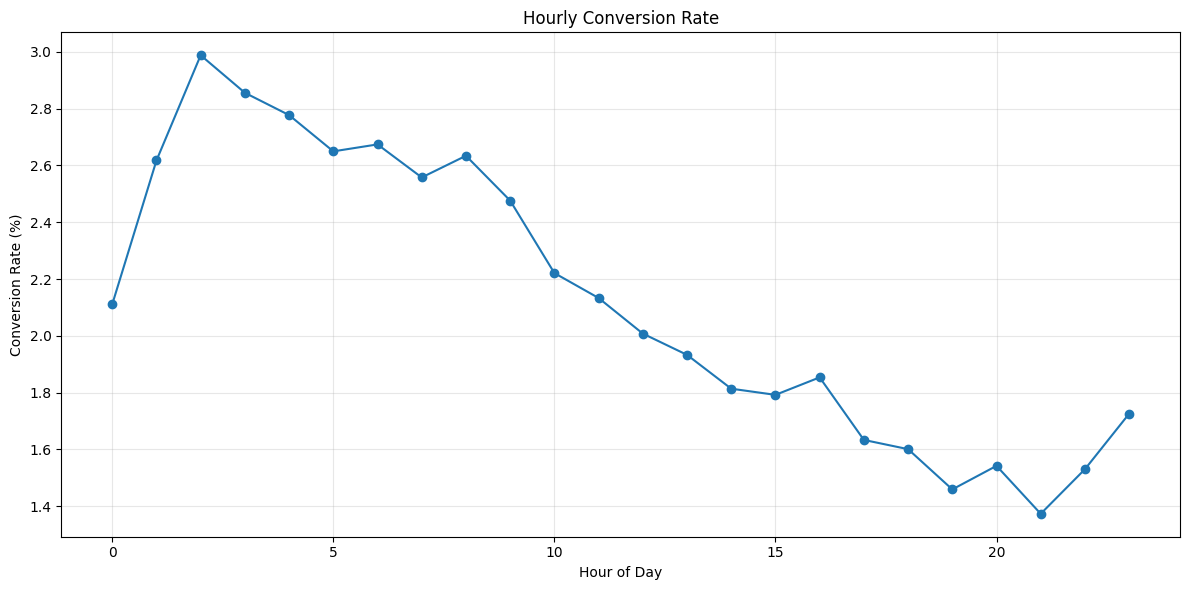

In [51]:
import matplotlib.pyplot as plt

# Visualize how conversion changes throughout the day
plt.figure(figsize=(12, 6))

plt.plot(
    hourly_stats.index,
    hourly_stats["conversion_rate"],
    marker="o"
)

plt.title("Hourly Conversion Rate")
plt.xlabel("Hour of Day")
plt.ylabel("Conversion Rate (%)")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Hourly Conversion Insights

- Conversion rates peak between 2 AM and 6 AM.
- The highest conversion rate occurs at 2 AM (2.99%).
- Conversion steadily declines throughout the day.
- Evening hours (7 PM–10 PM) show the weakest conversion performance.
- Users active late at night appear more purchase-oriented than casual browsers.


In [52]:
# Compare conversion behaviour on weekdays and weekends
weekend_stats = (
    df.groupby("is_weekend")
      .agg(
          views=("behavior_type",
                 lambda x: (x == "pv").sum()),
          purchases=("behavior_type",
                     lambda x: (x == "buy").sum())
      )
)

weekend_stats["conversion_rate"] = (
    weekend_stats["purchases"]
    / weekend_stats["views"]
    * 100
)

weekend_stats

,views,purchases,conversion_rate
is_weekend,,,
0,2321073,54563,2.350766
1,2099852,45490,2.166343


### Weekday vs Weekend Conversion

- Weekday conversion rate: 2.35%
- Weekend conversion rate: 2.17%
- Users are more likely to complete purchases during weekdays.
- Weekend traffic appears slightly more browsing-oriented.
- Promotional campaigns may generate better ROI during weekdays.

In [54]:
# Compare behaviour mix across user segments

segment_behavior = pd.crosstab(
    df["user_segment"],
    df["behavior_type"],
    normalize="index"
) * 100

segment_behavior.round(2)


behavior_type,buy,cart,fav,pv
user_segment,,,,
Buyer,7.65,5.67,2.66,84.01
Cart Abandoner,0.00,11.21,2.06,86.73
Passive Viewer,0.00,0.00,0.00,100.00
Wishlist Browser,0.00,0.00,12.40,87.60


# Cart abandoners show strong purchase intent but never complete checkout

In [55]:
# Compare cart adds and purchases by hour

hourly_funnel = (
    df.groupby("hour_of_day")
      .agg(
          carts=(
              "behavior_type",
              lambda x: (x == "cart").sum()
          ),
          purchases=(
              "behavior_type",
              lambda x: (x == "buy").sum()
          )
      )
)

hourly_funnel["cart_to_purchase_rate"] = (
    hourly_funnel["purchases"]
    / hourly_funnel["carts"]
    * 100
)

hourly_funnel.sort_values(
    "cart_to_purchase_rate",
    ascending=False
).head(10)

,carts,purchases,cart_to_purchase_rate
hour_of_day,,,
2,13360,6449,48.270958
4,12719,5896,46.355846
3,13070,6015,46.021423
6,13924,6226,44.714163
5,14041,6160,43.871519
8,14028,6061,43.206444
7,14347,6160,42.935805
1,11493,4866,42.338815
9,12707,5158,40.591800


In [56]:
# Check which categories generate the most purchases

top_purchase_categories = (
    df[df["behavior_type"] == "buy"]
    .groupby("category_id")
    .size()
    .sort_values(ascending=False)
    .head(20)
)

top_purchase_categories

category_id
1464116    1717
2735466    1703
2885642    1601
4145813    1572
4756105    1418
           ... 
570735      716
2465336     693
1879194     682
1299190     678
2355072     661
Length: 20, dtype: int64

# Check when users are most likely to complete a purchase
# after adding an item to their cart

In [57]:
# Check which hours convert carts into purchases most effectively

hourly_funnel = (
    df.groupby("hour_of_day")
      .agg(
          carts=("behavior_type",
                 lambda x: (x == "cart").sum()),
          purchases=("behavior_type",
                     lambda x: (x == "buy").sum())
      )
)

hourly_funnel["cart_to_purchase_rate"] = (
    hourly_funnel["purchases"]
    / hourly_funnel["carts"]
    * 100
)

hourly_funnel.sort_values(
    "cart_to_purchase_rate",
    ascending=False
)

,carts,purchases,cart_to_purchase_rate
hour_of_day,,,
2,13360,6449,48.270958
4,12719,5896,46.355846
3,13070,6015,46.021423
6,13924,6226,44.714163
5,14041,6160,43.871519
...,...,...,...
15,19925,5028,25.234630
20,1264,315,24.920886
22,3672,836,22.766885


Users who add products to their cart during late-night and
early-morning hours are nearly twice as likely to complete
a purchase compared to evening users.

Cart-to-purchase conversion peaks at 48.3% around 2 AM,
while evening conversion falls below 25%.


In [58]:
# Compare conversion performance across weekdays

daily_stats = (
    df.groupby("day_of_week")
      .agg(
          views=("behavior_type",
                 lambda x: (x == "pv").sum()),
          purchases=("behavior_type",
                     lambda x: (x == "buy").sum())
      )
)

daily_stats["conversion_rate"] = (
    daily_stats["purchases"]
    / daily_stats["views"]
    * 100
)

daily_stats.sort_values(
    "conversion_rate",
    ascending=False
)

,views,purchases,conversion_rate
day_of_week,,,
Monday,447076,10925,2.443656
Wednesday,460654,11244,2.440878
Thursday,472375,11237,2.378830
Tuesday,441589,10474,2.371889
Sunday,1005914,22342,2.221065
Friday,499379,10683,2.139257
Saturday,1093938,23148,2.116025


Schedule high-value promotions and retargeting campaigns
between Monday and Thursday when purchase intent is strongest.

Use weekends for awareness campaigns, product discovery,
and wishlist-building activities.


| KPI                   |                   Value |
| --------------------- | ----------------------: |
| Total Events          |               4,937,815 |
| Total Users           |                 376,483 |
| Purchase Events       |                 100,053 |
| Cart Events           |                 277,476 |
| Favorite Events       |                 144,415 |
| Page Views            |               4,415,871 |
| Cart Abandonment Rate |                  45.82% |
| Best Conversion Hour  |                    2 AM |
| Best Conversion Day   |                  Monday |
| Largest User Segment  | Cart Abandoner (36.14%) |


# E-Commerce Funnel Optimization & User Behavior Analytics

## Project Overview

This project analyzes customer interactions from the Taobao User Behavior dataset to understand shopping patterns, identify conversion bottlenecks, segment users, and generate actionable business insights.

A statistically representative sample of 5 million records was extracted from the original dataset using Reservoir Sampling. After cleaning and validation, the final dataset contained approximately 4.94 million user interactions across 376,483 unique users.

---

# Data Preparation

## Data Cleaning

The following preprocessing steps were performed:

* Removed invalid and corrupted timestamp records.
* Validated event types (pv, fav, cart, buy).
* Converted Unix timestamps into datetime format.
* Extracted temporal features such as hour, day, and date.
* Removed inconsistent records outside the valid observation window.

### Final Dataset

| Metric          |     Value |
| --------------- | --------: |
| Total Events    | 4,937,815 |
| Unique Users    |   376,483 |
| Purchase Events |   100,053 |
| Cart Events     |   277,476 |
| Favorite Events |   144,415 |
| Page Views      | 4,415,871 |

---

# Feature Engineering

Additional features were created to better understand user behavior.

### Temporal Features

* Hour of Day
* Day of Week
* Weekend Indicator
* Hour Segment (Morning, Afternoon, Evening, etc.)

### Behavioral Features

* Previous User Action
* Next User Action
* Action Sequences
* Time Between Actions

### Session Features

User sessions were constructed using a 30-minute inactivity threshold.

Generated features include:

* Session ID
* Session Number
* Time Difference Between Events
* New Session Indicator

### User Segmentation

Users were grouped into four behavioral segments:

* Buyer
* Cart Abandoner
* Wishlist Browser
* Passive Viewer

---

# Bot Detection Analysis

Multiple indicators were used to identify suspicious activity:

* User activity frequency
* Zero-duration session analysis
* Repeated interactions on the same product
* Session behavior patterns

### Findings

* No strong evidence of large-scale bot activity was detected.
* A small set of highly active users was identified.
* These users still exhibited meaningful shopping behavior, including cart additions and purchases.

### Decision

Rather than removing users, a `bot_flag` feature was created to preserve potentially valuable customer behavior while allowing future analysis.

---

# Funnel Analysis

The shopping funnel was analyzed to understand where users drop off during the purchase journey.

### Conversion Metrics

| Metric                |  Value |
| --------------------- | -----: |
| View → Favorite       | 18.40% |
| Cart → Purchase       | 54.18% |
| View → Purchase       | 21.15% |
| Cart Abandonment Rate | 45.82% |

### Key Insight

Nearly half of users who add products to their cart do not complete the purchase process.

This represents the largest source of revenue leakage within the funnel.

---

# User Segmentation Analysis

| Segment          | Share of Activity |
| ---------------- | ----------------: |
| Cart Abandoner   |            36.14% |
| Buyer            |            26.49% |
| Passive Viewer   |            25.77% |
| Wishlist Browser |            11.59% |

## Buyer Profile

| Action    | Percentage |
| --------- | ---------: |
| Page View |     84.01% |
| Favorite  |      2.66% |
| Cart      |      5.67% |
| Purchase  |      7.65% |

## Cart Abandoner Profile

| Action    | Percentage |
| --------- | ---------: |
| Page View |     86.73% |
| Favorite  |      2.06% |
| Cart      |     11.21% |
| Purchase  |      0.00% |

## Wishlist Browser Profile

| Action    | Percentage |
| --------- | ---------: |
| Page View |     87.60% |
| Favorite  |     12.40% |
| Purchase  |      0.00% |

## Passive Viewer Profile

| Action    | Percentage |
| --------- | ---------: |
| Page View |    100.00% |

### Key Insight

Cart Abandoners represent the largest user segment and offer the greatest opportunity for conversion improvement.

---

# Temporal Analysis

## Hourly Conversion Performance

### Best Conversion Hours

| Hour | Conversion Rate |
| ---- | --------------: |
| 2 AM |           2.99% |
| 3 AM |           2.86% |
| 4 AM |           2.78% |
| 6 AM |           2.67% |
| 5 AM |           2.65% |

### Highest Cart-to-Purchase Hours

| Hour | Cart → Purchase Rate |
| ---- | -------------------: |
| 2 AM |               48.27% |
| 4 AM |               46.36% |
| 3 AM |               46.02% |
| 6 AM |               44.71% |
| 5 AM |               43.87% |

### Lowest Cart-to-Purchase Hours

| Hour  | Cart → Purchase Rate |
| ----- | -------------------: |
| 9 PM  |               20.27% |
| 7 PM  |               22.35% |
| 10 PM |               22.77% |
| 8 PM  |               24.92% |
| 3 PM  |               25.23% |

### Key Insight

Users active during late-night and early-morning hours exhibit significantly higher purchase intent than users browsing during evening hours.

---

# Day-of-Week Analysis

| Day       | Conversion Rate |
| --------- | --------------: |
| Monday    |           2.44% |
| Wednesday |           2.44% |
| Thursday  |           2.38% |
| Tuesday   |           2.37% |
| Sunday    |           2.22% |
| Friday    |           2.14% |
| Saturday  |           2.12% |

## Weekday vs Weekend

| Period  | Conversion Rate |
| ------- | --------------: |
| Weekday |           2.35% |
| Weekend |           2.17% |

### Key Insight

Weekday visitors show stronger purchase intent than weekend visitors, suggesting that weekends are used more for browsing and product exploration.

---

# Category Performance

### Top Categories by Purchase Volume

| Category ID |
| ----------- |
| 1464116     |
| 2735466     |
| 2885642     |
| 4145813     |
| 4756105     |

### Key Insight

A relatively small number of categories generate a disproportionate share of purchases, making them strong candidates for promotional investment and inventory prioritization.

---

# Business Recommendations

## Reduce Cart Abandonment

* Implement cart reminder notifications.
* Offer limited-time incentives.
* Simplify checkout flow.
* Reduce checkout friction.

## Improve Wishlist Conversion

* Trigger price-drop alerts.
* Send personalized product recommendations.
* Create wishlist-based remarketing campaigns.

## Optimize Campaign Timing

* Focus promotions during high-conversion periods between 2 AM and 6 AM.
* Prioritize Monday–Thursday for performance-focused campaigns.

## Prioritize High-Performing Categories

* Allocate additional marketing spend to top-performing categories.
* Ensure inventory availability for high-demand categories.
* Use category-level recommendations to improve conversion.

---

# Conclusion

The analysis identified cart abandonment as the primary source of revenue leakage and revealed strong differences in purchasing behavior across user segments and time periods.

Cart Abandoners emerged as the largest behavioral segment, while late-night and early-morning users demonstrated the strongest purchase intent. Category-level analysis further highlighted a small group of product categories responsible for a significant share of purchases.

These findings provide a clear foundation for conversion optimization, personalized marketing strategies, and data-driven business decision-making.
